In [ ]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

Saving cleaned_online_retail.csv to cleaned_online_retail.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_online_retail.csv")

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and columns: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from scipy.spatial.distance import mahalanobis
from scipy.stats import skew

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Load cleaned dataset
df = pd.read_csv("cleaned_online_retail.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 392692
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 27.0+ MB


In [ ]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(df) * 100).round(2)
})

missing_df

,Missing Count,Missing %
InvoiceNo,0,0.00
StockCode,0,0.00
Description,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,0,0.00
Country,0,0.00
TotalAmount,0,0.00


In [ ]:
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

unique_summary

,Column,Unique Values
0,InvoiceNo,18532
1,StockCode,3665
2,Description,3877
3,Quantity,301
4,InvoiceDate,17282
5,UnitPrice,440
6,CustomerID,4338
7,Country,37
8,TotalAmount,2810


Customer Behaviour EDA

Customer-level aggregation

In [ ]:
customer_eda = df.groupby("CustomerID").agg(
    Revenue=("TotalAmount", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Quantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique")
)

customer_eda["AOV"] = (
    customer_eda["Revenue"] / customer_eda["Orders"]
)

customer_eda.head()

,Revenue,Orders,Quantity,UniqueProducts,AOV
CustomerID,,,,,
12346,"77,183.60",1,74215,1,"77,183.60"
12347,"4,310.00",7,2458,103,615.71
12348,"1,797.24",4,2341,22,449.31
12349,"1,757.55",1,631,73,"1,757.55"
12350,334.40,1,197,17,334.40


Customer statistics

In [ ]:
customer_eda.describe()

,Revenue,Orders,Quantity,UniqueProducts,AOV
count,"4,338.00","4,338.00","4,338.00","4,338.00","4,338.00"
mean,"2,048.69",4.27,"1,187.64",61.50,417.65
std,"8,985.23",7.70,"5,043.62",85.37,"1,796.51"
min,3.75,1.00,1.00,1.00,3.45
25%,306.48,1.00,159.00,16.00,177.87
50%,668.57,2.00,378.00,35.00,291.94
75%,"1,660.60",5.00,989.75,77.00,428.28
max,"280,206.02",209.00,"196,915.00","1,787.00","84,236.25"


Revenue distribution

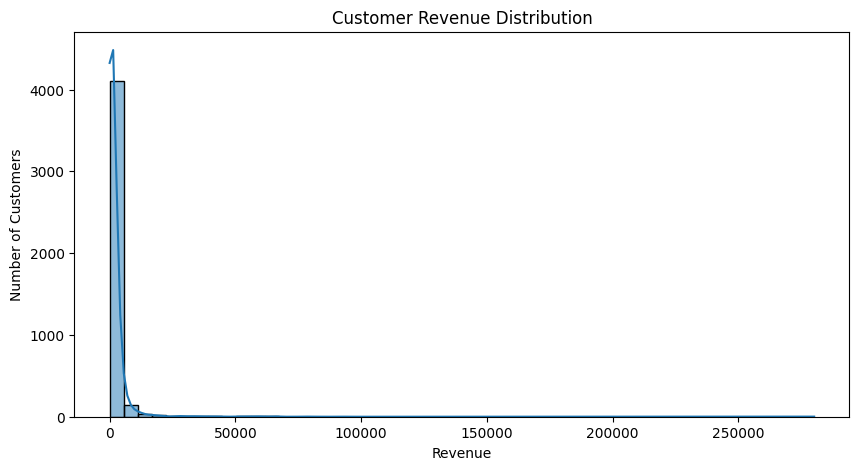

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_eda["Revenue"],
    bins=50,
    kde=True
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Customers")
plt.show()

Log revenue distribution

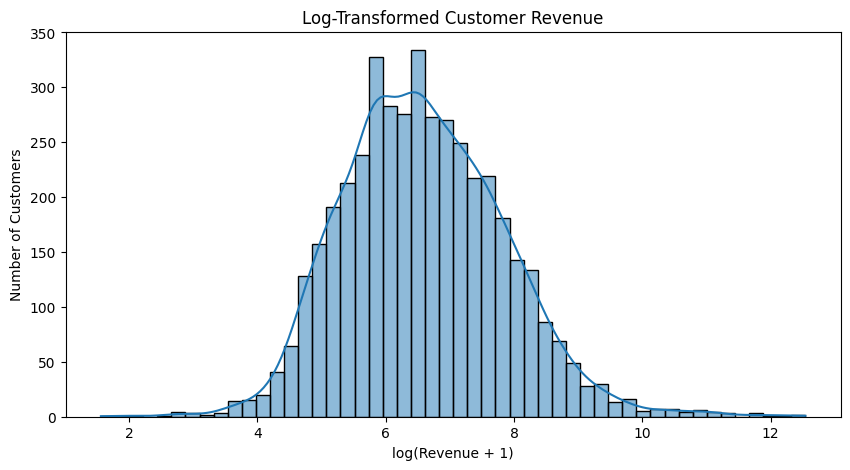

In [ ]:
customer_eda["LogRevenue"] = np.log1p(customer_eda["Revenue"])

plt.figure(figsize=(10, 5))

sns.histplot(
    customer_eda["LogRevenue"],
    bins=50,
    kde=True
)

plt.title("Log-Transformed Customer Revenue")
plt.xlabel("log(Revenue + 1)")
plt.ylabel("Number of Customers")
plt.show()

Orders per customer

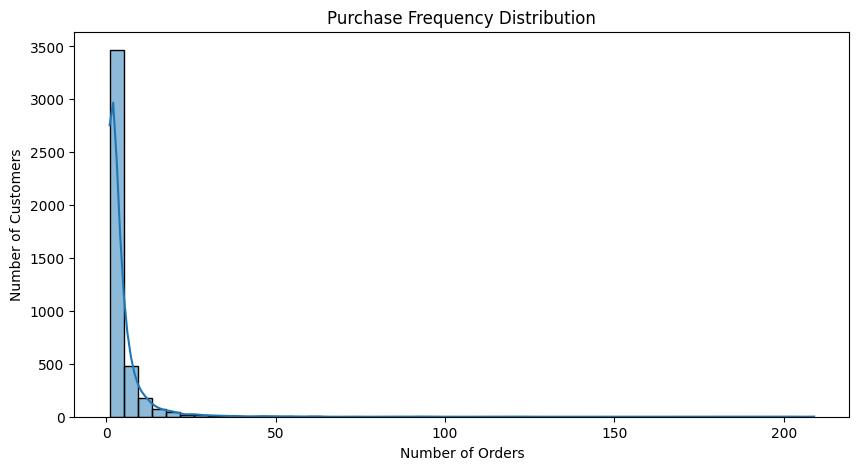

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_eda["Orders"],
    bins=50,
    kde=True
)

plt.title("Purchase Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

Quantity per customer

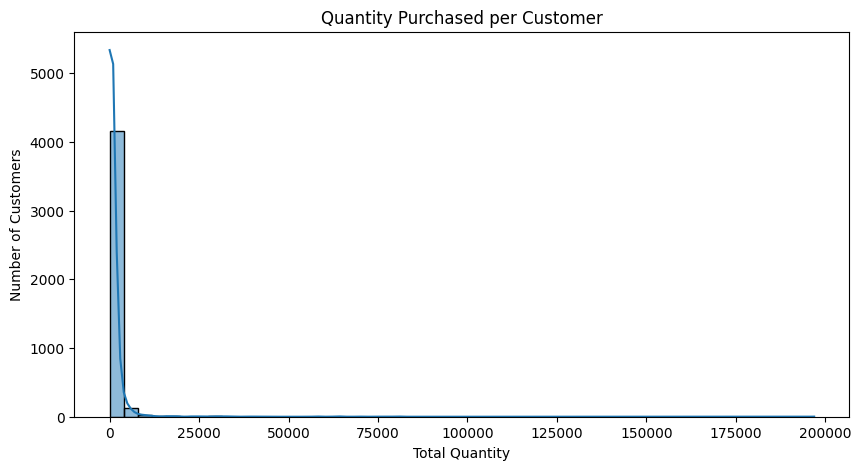

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_eda["Quantity"],
    bins=50,
    kde=True
)

plt.title("Quantity Purchased per Customer")
plt.xlabel("Total Quantity")
plt.ylabel("Number of Customers")
plt.show()

Product Analysis

Top products by quantity

In [ ]:
top_quantity = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


plot

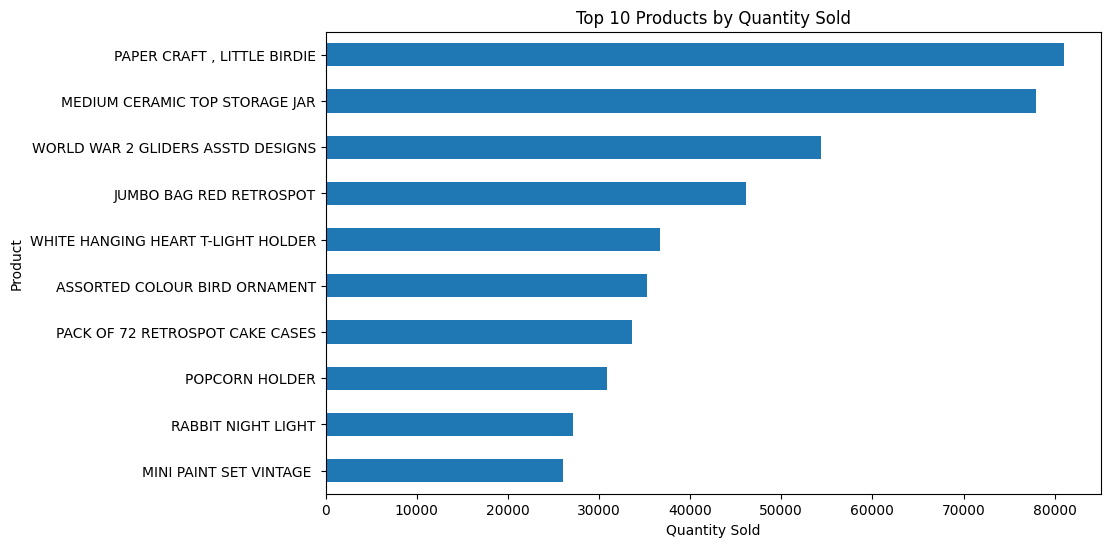

In [ ]:
plt.figure(figsize=(10, 6))

top_quantity.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

Top products by revenue

In [ ]:
top_revenue = (
    df.groupby("Description")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue

,TotalAmount
Description,
"PAPER CRAFT , LITTLE BIRDIE","168,469.60"
REGENCY CAKESTAND 3 TIER,"142,264.75"
WHITE HANGING HEART T-LIGHT HOLDER,"100,392.10"
JUMBO BAG RED RETROSPOT,"85,040.54"
MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73"
POSTAGE,"77,803.96"
PARTY BUNTING,"68,785.23"
ASSORTED COLOUR BIRD ORNAMENT,"56,413.03"
Manual,"53,419.93"


plot

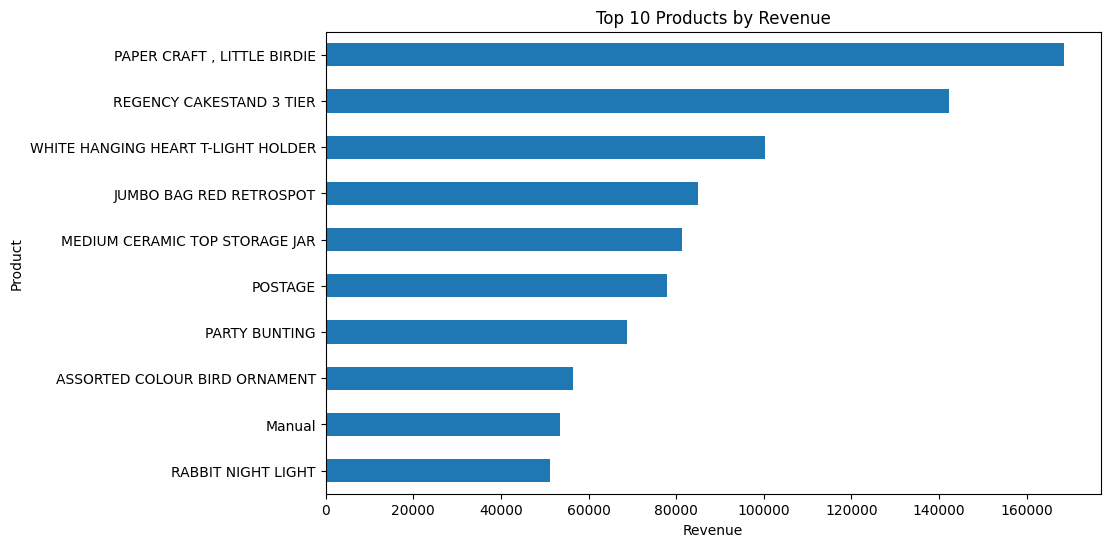

In [ ]:
plt.figure(figsize=(10, 6))

top_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

Most frequently purchased products

In [ ]:
top_frequency = (
    df.groupby("Description")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_frequency

,InvoiceNo
Description,
WHITE HANGING HEART T-LIGHT HOLDER,1971
REGENCY CAKESTAND 3 TIER,1703
JUMBO BAG RED RETROSPOT,1600
PARTY BUNTING,1379
ASSORTED COLOUR BIRD ORNAMENT,1375
LUNCH BAG RED RETROSPOT,1288
SET OF 3 CAKE TINS PANTRY DESIGN,1146
POSTAGE,1099
LUNCH BAG BLACK SKULL.,1052


Plot

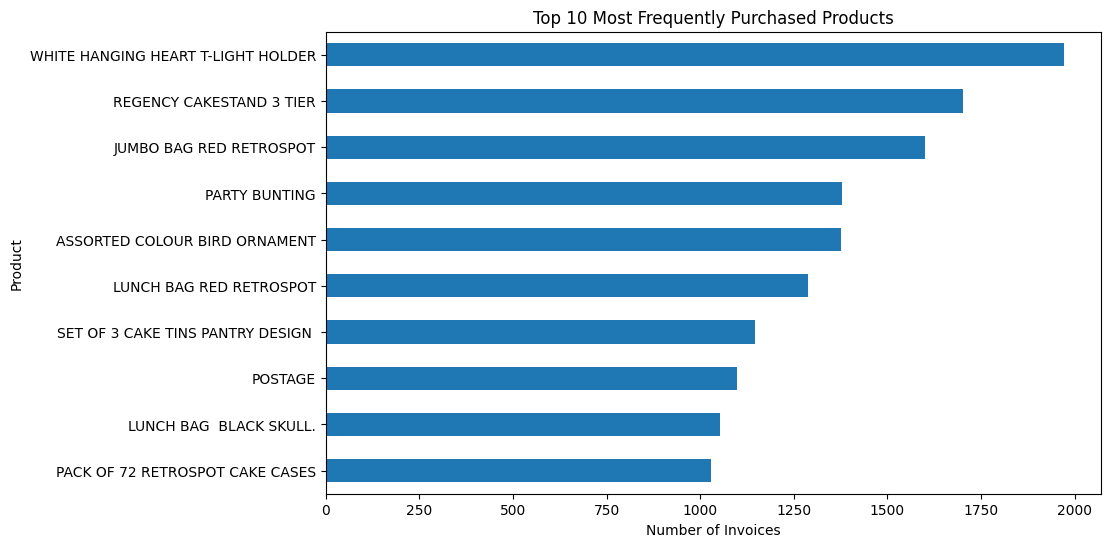

In [ ]:
plt.figure(figsize=(10, 6))

top_frequency.sort_values().plot(kind="barh")

plt.title("Top 10 Most Frequently Purchased Products")
plt.xlabel("Number of Invoices")
plt.ylabel("Product")

plt.show()

Product price distribution

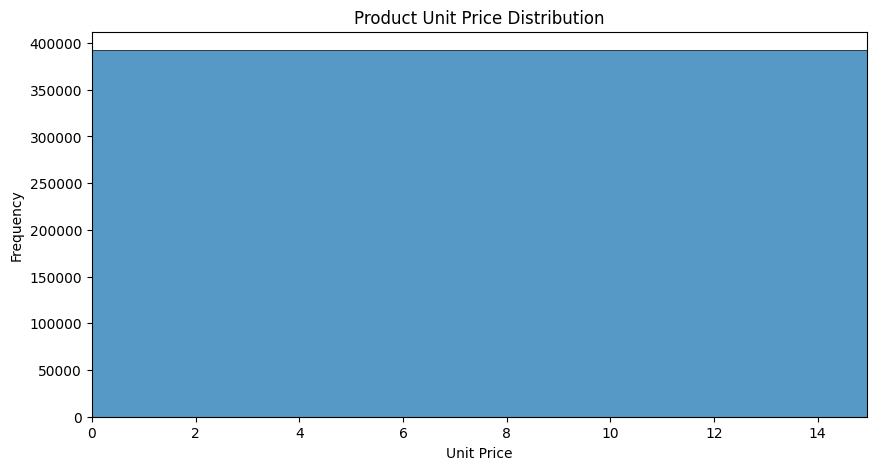

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["UnitPrice"],
    bins=100
)

plt.xlim(0, df["UnitPrice"].quantile(0.99))

plt.title("Product Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

Basket / Transaction Analysis

Create invoice-level dataset

In [ ]:
invoice_eda = df.groupby("InvoiceNo").agg(
    BasketItems=("Quantity", "sum"),
    BasketValue=("TotalAmount", "sum"),
    UniqueProducts=("StockCode", "nunique")
)

invoice_eda.describe()

,BasketItems,BasketValue,UniqueProducts
count,"18,532.00","18,532.00","18,532.00"
mean,278.01,479.56,20.93
std,972.39,"1,678.08",23.82
min,1.00,0.38,1.00
25%,74.00,157.34,6.00
50%,154.00,302.57,15.00
75%,290.00,469.57,27.00
max,"80,995.00","168,469.60",541.00


Basket value distribution

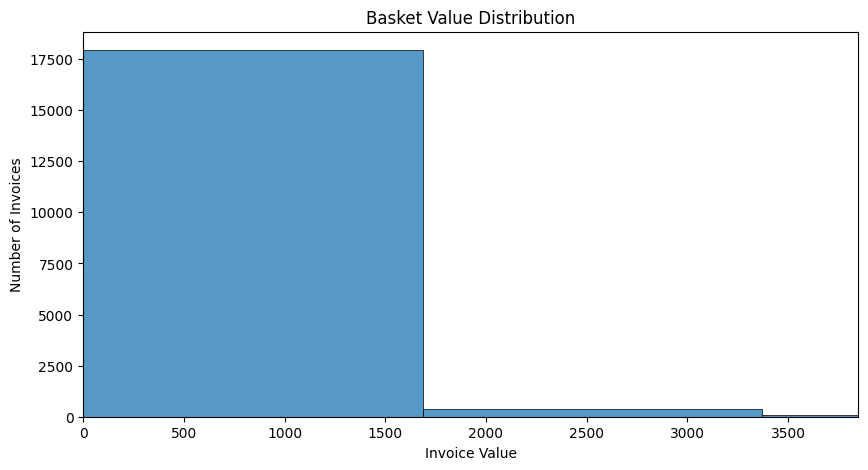

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    invoice_eda["BasketValue"],
    bins=100
)

plt.xlim(
    0,
    invoice_eda["BasketValue"].quantile(0.99)
)

plt.title("Basket Value Distribution")
plt.xlabel("Invoice Value")
plt.ylabel("Number of Invoices")

plt.show()

Items per invoice

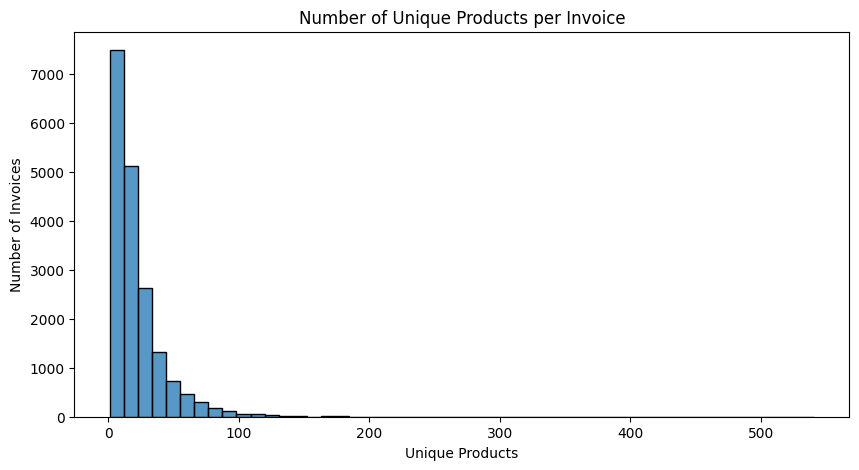

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    invoice_eda["UniqueProducts"],
    bins=50
)

plt.title("Number of Unique Products per Invoice")
plt.xlabel("Unique Products")
plt.ylabel("Number of Invoices")

plt.show()

Time-Based EDA

Create time features

In [ ]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthYear"] = df["InvoiceDate"].dt.to_period("M")

df["Weekday"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

Monthly transaction count

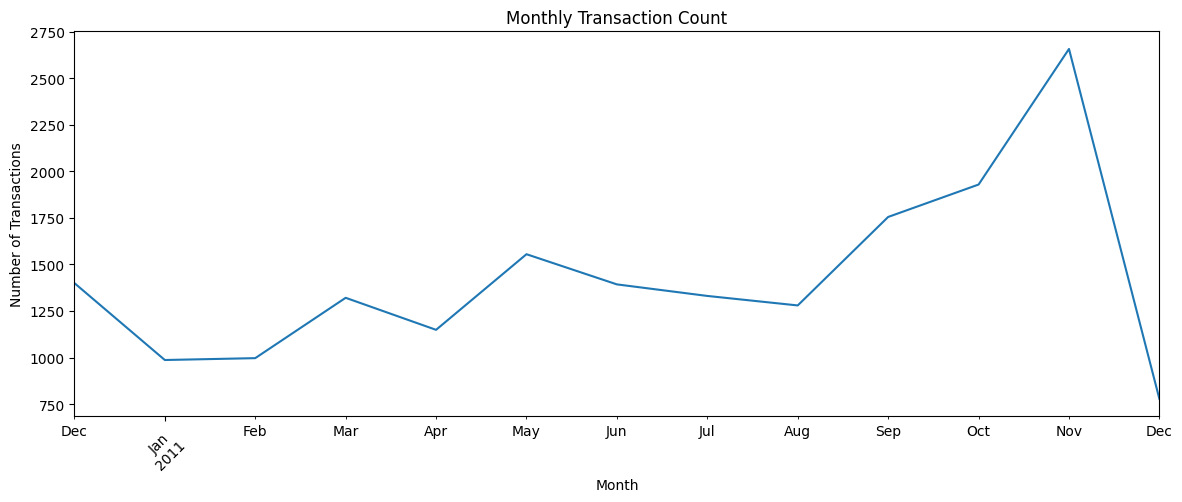

In [ ]:
monthly_transactions = (
    df.groupby("MonthYear")["InvoiceNo"]
    .nunique()
)

plt.figure(figsize=(14, 5))

monthly_transactions.plot()

plt.title("Monthly Transaction Count")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

Monthly revenue

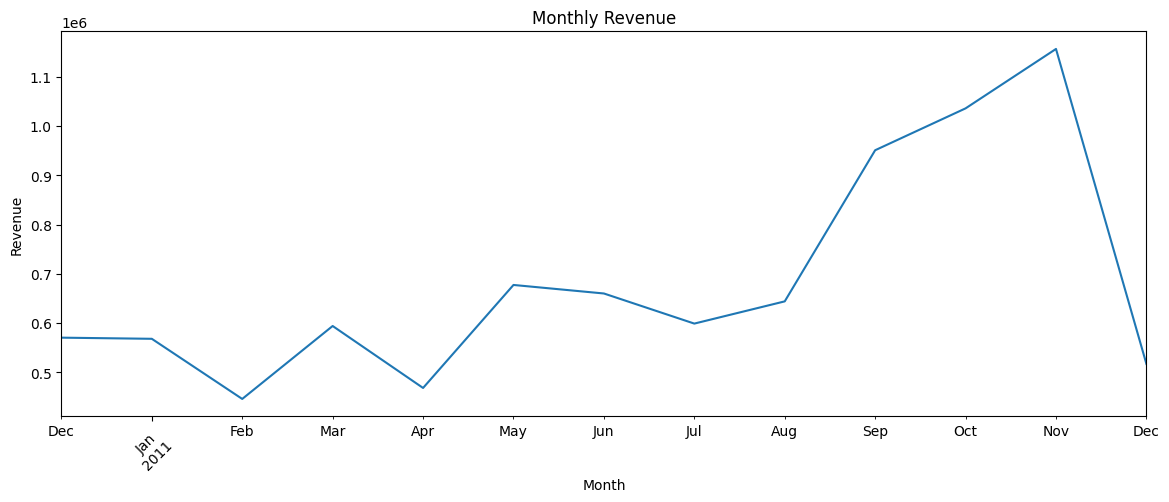

In [ ]:
monthly_revenue = (
    df.groupby("MonthYear")["TotalAmount"]
    .sum()
)

plt.figure(figsize=(14, 5))

monthly_revenue.plot()

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

Monthly quantity

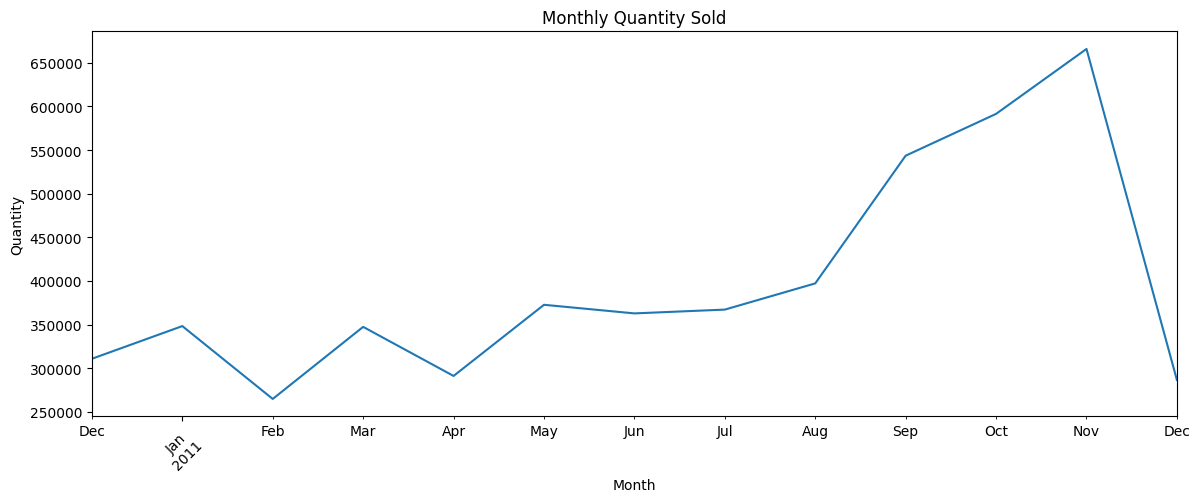

In [ ]:
monthly_quantity = (
    df.groupby("MonthYear")["Quantity"]
    .sum()
)

plt.figure(figsize=(14, 5))

monthly_quantity.plot()

plt.title("Monthly Quantity Sold")
plt.xlabel("Month")
plt.ylabel("Quantity")

plt.xticks(rotation=45)

plt.show()

Weekday transaction analysis

In [ ]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_transactions = (
    df.groupby("Weekday")["InvoiceNo"]
    .nunique()
    .reindex(weekday_order)
)

weekday_transactions

,InvoiceNo
Weekday,
Monday,"2,863.00"
Tuesday,"3,184.00"
Wednesday,"3,455.00"
Thursday,"4,032.00"
Friday,"2,829.00"
Saturday,NaN
Sunday,"2,169.00"


Plot

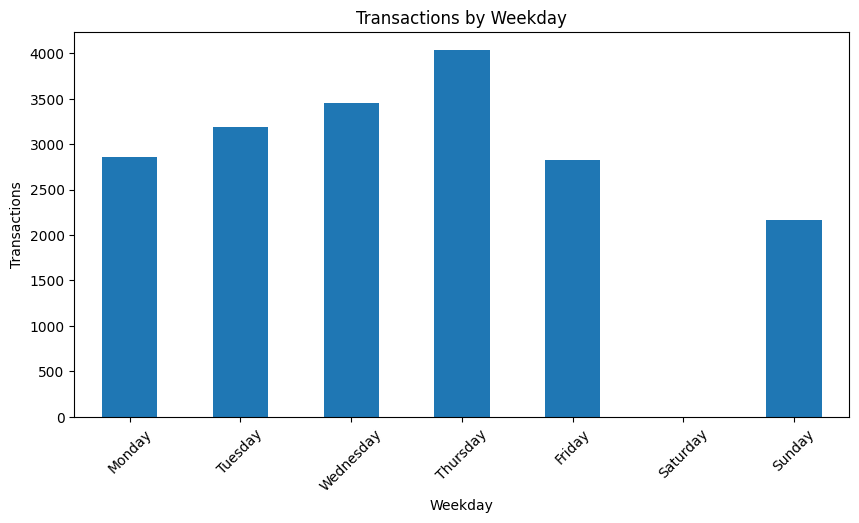

In [ ]:
plt.figure(figsize=(10, 5))

weekday_transactions.plot(kind="bar")

plt.title("Transactions by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Transactions")

plt.xticks(rotation=45)

plt.show()

Hourly purchasing pattern

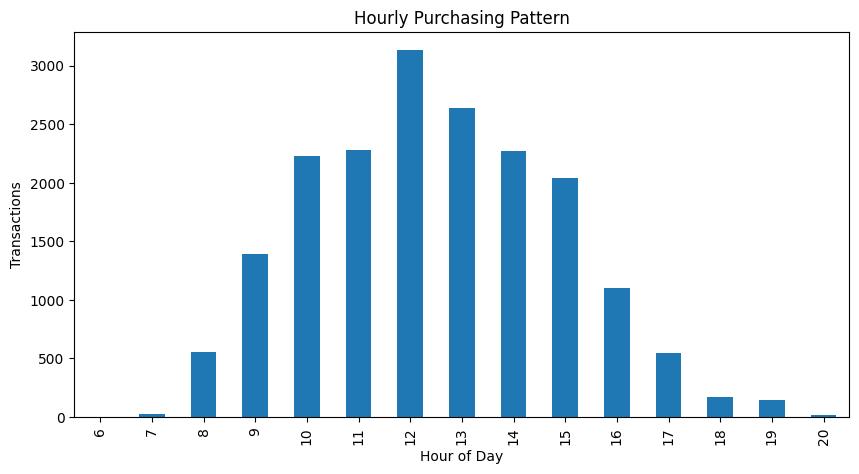

In [ ]:
hourly_transactions = (
    df.groupby("Hour")["InvoiceNo"]
    .nunique()
)

plt.figure(figsize=(10, 5))

hourly_transactions.plot(kind="bar")

plt.title("Hourly Purchasing Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Transactions")

plt.show()

Country Analysis

Country summary

In [ ]:
country_eda = df.groupby("Country").agg(
    Customers=("CustomerID", "nunique"),
    Transactions=("InvoiceNo", "nunique"),
    Revenue=("TotalAmount", "sum"),
    Quantity=("Quantity", "sum")
)

country_eda["AOV"] = (
    country_eda["Revenue"] /
    country_eda["Transactions"]
)

country_eda.sort_values(
    "Revenue",
    ascending=False
).head(10)

,Customers,Transactions,Revenue,Quantity,AOV
Country,,,,,
United Kingdom,3920,16646,"7,285,024.64",4241305,437.64
Netherlands,9,94,"285,446.34",200361,"3,036.66"
EIRE,3,260,"265,262.46",140133,"1,020.24"
Germany,94,457,"228,678.40",119154,500.39
France,87,389,"208,934.31",111428,537.11
Australia,9,57,"138,453.81",83891,"2,429.01"
Spain,30,90,"61,558.56",27933,683.98
Switzerland,21,51,"56,443.95",30082,"1,106.74"
Belgium,25,98,"41,196.34",23237,420.37


Outlier Analysis

IQR outlier detection

In [ ]:
def iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return lower, upper


q_lower, q_upper = iqr_outliers(df["Quantity"])

print("Quantity Lower Bound:", q_lower)
print("Quantity Upper Bound:", q_upper)

quantity_outliers = df[
    (df["Quantity"] < q_lower) |
    (df["Quantity"] > q_upper)
]

print("Quantity outliers:", len(quantity_outliers))

Quantity Lower Bound: -13.0
Quantity Upper Bound: 27.0
Quantity outliers: 25616


UnitPrice outliers

In [ ]:
p_lower, p_upper = iqr_outliers(df["UnitPrice"])

price_outliers = df[
    (df["UnitPrice"] < p_lower) |
    (df["UnitPrice"] > p_upper)
]

print("Price outliers:", len(price_outliers))

Price outliers: 34112


TotalAmount outliers

In [ ]:
a_lower, a_upper = iqr_outliers(df["TotalAmount"])

amount_outliers = df[
    (df["TotalAmount"] < a_lower) |
    (df["TotalAmount"] > a_upper)
]

print("TotalAmount outliers:", len(amount_outliers))

TotalAmount outliers: 31231


Isolation Forest

In [ ]:
outlier_features = df[
    ["Quantity", "UnitPrice", "TotalAmount"]
].copy()

iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

df["IsolationOutlier"] = iso.fit_predict(outlier_features)

In [ ]:
df["IsolationOutlier"].value_counts()

,count
IsolationOutlier,
1,388770
-1,3922


In [ ]:
isolation_outliers = df[
    df["IsolationOutlier"] == -1
]

isolation_outliers[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "TotalAmount"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,TotalAmount
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,10.95,350.40
176,536387,79321,CHILLI LIGHTS,192,3.82,733.44
177,536387,22780,LIGHT GARLAND BUTTERFILES PINK,192,3.37,647.04
178,536387,22779,WOODEN OWLS LIGHT GARLAND,192,3.37,647.04
179,536387,22466,FAIRY TALE COTTAGE NIGHTLIGHT,432,1.45,626.40
180,536387,21731,RED TOADSTOOL LED NIGHT LIGHT,432,1.25,540.00
217,536390,20668,DISCO BALL CHRISTMAS DECORATION,288,0.10,28.80
237,536392,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,1,165.00,165.00
406,536405,20914,SET/5 RED RETROSPOT LID GLASS BOWLS,128,2.55,326.40
701,536437,21154,RED RETROSPOT OVEN GLOVE,200,1.06,212.00


Mahalanobis Distance

In [ ]:
features = df[
    ["Quantity", "UnitPrice", "TotalAmount"]
].values

mean_vector = np.mean(features, axis=0)

cov_matrix = np.cov(features, rowvar=False)

cov_inverse = np.linalg.pinv(cov_matrix)

mahalanobis_distance = np.array([
    mahalanobis(
        x,
        mean_vector,
        cov_inverse
    )
    for x in features
])

df["MahalanobisDistance"] = mahalanobis_distance

In [ ]:
df[
    ["Quantity", "UnitPrice", "TotalAmount", "MahalanobisDistance"]
].sort_values(
    "MahalanobisDistance",
    ascending=False
).head(20)

,Quantity,UnitPrice,TotalAmount,MahalanobisDistance
392226,80995,2.08,"168,469.60",557.69
36521,74215,1.04,"77,183.60",523.32
116868,1,"8,142.75","8,142.75",366.20
153588,60,649.50,"38,970.00",311.00
305365,1,"4,161.06","4,161.06",187.07
305341,1,"4,161.06","4,161.06",187.07
292020,1,"3,949.32","3,949.32",177.54
266726,1,"3,155.95","3,155.95",141.85
206437,1,"2,500.00","2,500.00",112.33
95757,1,"2,382.92","2,382.92",107.07


Correlation Analysis

The project explicitly requires

1.Quantity vs TotalAmount
2.UnitPrice vs TotalAmount
3.Quantity vs UnitPrice
4.correlation heatmap





Correlation matrix

In [ ]:
correlation_cols = [
    "Quantity",
    "UnitPrice",
    "TotalAmount"
]

corr = df[correlation_cols].corr()

corr

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Advanced Customer-Level EDA

Now we prepare the actual RFM features

.Recency = how recently the customer purchased
.Frequency = how often they purchased
.Monetary = how much they spent.



In [ ]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x:
             (reference_date - x.max()).days),

    Frequency=("InvoiceNo", "nunique"),

    Monetary=("TotalAmount", "sum")
)

rfm["AOV"] = (
    rfm["Monetary"] /
    rfm["Frequency"]
)

rfm["TotalQuantity"] = (
    df.groupby("CustomerID")["Quantity"]
    .sum()
)

rfm["UniqueProducts"] = (
    df.groupby("CustomerID")["StockCode"]
    .nunique()
)

rfm.head()

RFM distributions

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=40, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.show()

Log-transform skewed variables

This is especially important before K-Means.

In [ ]:
rfm["LogFrequency"] = np.log1p(rfm["Frequency"])
rfm["LogMonetary"] = np.log1p(rfm["Monetary"])
rfm["LogAOV"] = np.log1p(rfm["AOV"])
rfm["LogQuantity"] = np.log1p(rfm["TotalQuantity"])
rfm["LogUniqueProducts"] = np.log1p(rfm["UniqueProducts"])

Check skewness:

In [ ]:
skewness = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "AOV",
        "TotalQuantity",
        "UniqueProducts"
    ]
].skew()

skewness.sort_values(ascending=False)

Recency vs Monetary

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    alpha=0.5
)

plt.title("Recency vs Monetary")
plt.xlabel("Recency (days)")
plt.ylabel("Monetary Value")

plt.show()

Frequency vs Monetary

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    alpha=0.5
)

plt.title("Frequency vs Monetary")
plt.xlabel("Number of Orders")
plt.ylabel("Monetary Value")

plt.show()

Frequency vs Recency

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    alpha=0.5
)

plt.title("Frequency vs Recency")
plt.xlabel("Recency")
plt.ylabel("Frequency")

plt.show()

Customer Pareto Analysis

Revenue concentration

In [ ]:
customer_revenue = (
    rfm["Monetary"]
    .sort_values(ascending=False)
)

customer_revenue_share = (
    customer_revenue.cumsum() /
    customer_revenue.sum()
)

customer_revenue_share.head(10)

Calculate top 20%

In [ ]:
top_20_count = int(len(customer_revenue) * 0.20)

top_20_revenue = (
    customer_revenue.iloc[:top_20_count].sum()
)

total_revenue = customer_revenue.sum()

percentage = (
    top_20_revenue / total_revenue * 100
)

print(
    f"Top 20% customers generate approximately "
    f"{percentage:.2f}% of revenue."
)

Spending vs Product Diversity

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="UniqueProducts",
    y="Monetary",
    alpha=0.5
)

plt.title("Customer Spending vs Product Diversity")
plt.xlabel("Unique Products Purchased")
plt.ylabel("Monetary Value")

plt.show()

Spending vs Number of Orders

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    alpha=0.5
)

plt.title("Customer Spending vs Number of Orders")
plt.xlabel("Orders")
plt.ylabel("Revenue")

plt.show()